In [21]:
# Install dependencies for this notebook (runs in the kernel)
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


# LLM Serving Benchmark Analysis

Comparing latency under concurrent load for different model sizes.

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

df = pd.read_csv('../results/results.csv')
numeric_cols = ['concurrency', 'requested', 'success_count', 'failure_count', 'avg_latency', 'min_latency', 'p50_latency', 'p95_latency', 'p99_latency', 'max_latency', 'total_tokens', 'avg_tokens', 'tokens_per_sec', 'requests_per_sec', 'duration']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['model_size'] = df['model'].apply(lambda x: 'small' if '1b' in x else 'large' if '7b' in x else x)
df['prompt_slug'] = df['prompt'].str.replace(r'[^A-Za-z0-9]+', '_', regex=True).str.strip('_')

print(f'Loaded {len(df)} rows from results.csv')
print('Prompts:', df['prompt'].nunique())
print('Models:', df['model'].nunique())
print('Devices:', df['device'].nunique())
df.head()


Loaded 64 rows from results.csv
Prompts: 4
Models: 2
Devices: 2


,prompt,model,device,concurrency,requested,success_count,failure_count,avg_latency,min_latency,p50_latency,p95_latency,p99_latency,max_latency,total_tokens,avg_tokens,tokens_per_sec,requests_per_sec,duration,model_size,prompt_slug
0,Say hello in one word,llama3.2:1b,cpu,1,48,48,0,0.132194,0.121846,0.130661,0.143006,0.168192,0.168192,48,1.0,7.564663,7.564663,6.345293,small,Say_hello_in_one_word
1,Say hello in one word,llama3.2:1b,cpu,2,48,48,0,0.153307,0.127192,0.150926,0.173742,0.176711,0.176711,48,1.0,6.522861,6.522861,7.358734,small,Say_hello_in_one_word
2,Say hello in one word,llama3.2:1b,cpu,4,48,48,0,0.233943,0.135629,0.182962,0.331207,0.342918,0.342918,48,1.0,4.274549,4.274549,11.229255,small,Say_hello_in_one_word
3,Say hello in one word,llama3.2:1b,cpu,8,48,48,0,0.391896,0.144121,0.343701,0.633415,0.650850,0.650850,48,1.0,2.551700,2.551700,18.810990,small,Say_hello_in_one_word
4,Say hello in one word,llama3.2:1b,gpu,1,48,48,0,0.134204,0.124815,0.134592,0.141826,0.148107,0.148107,48,1.0,7.451366,7.451366,6.441772,small,Say_hello_in_one_word


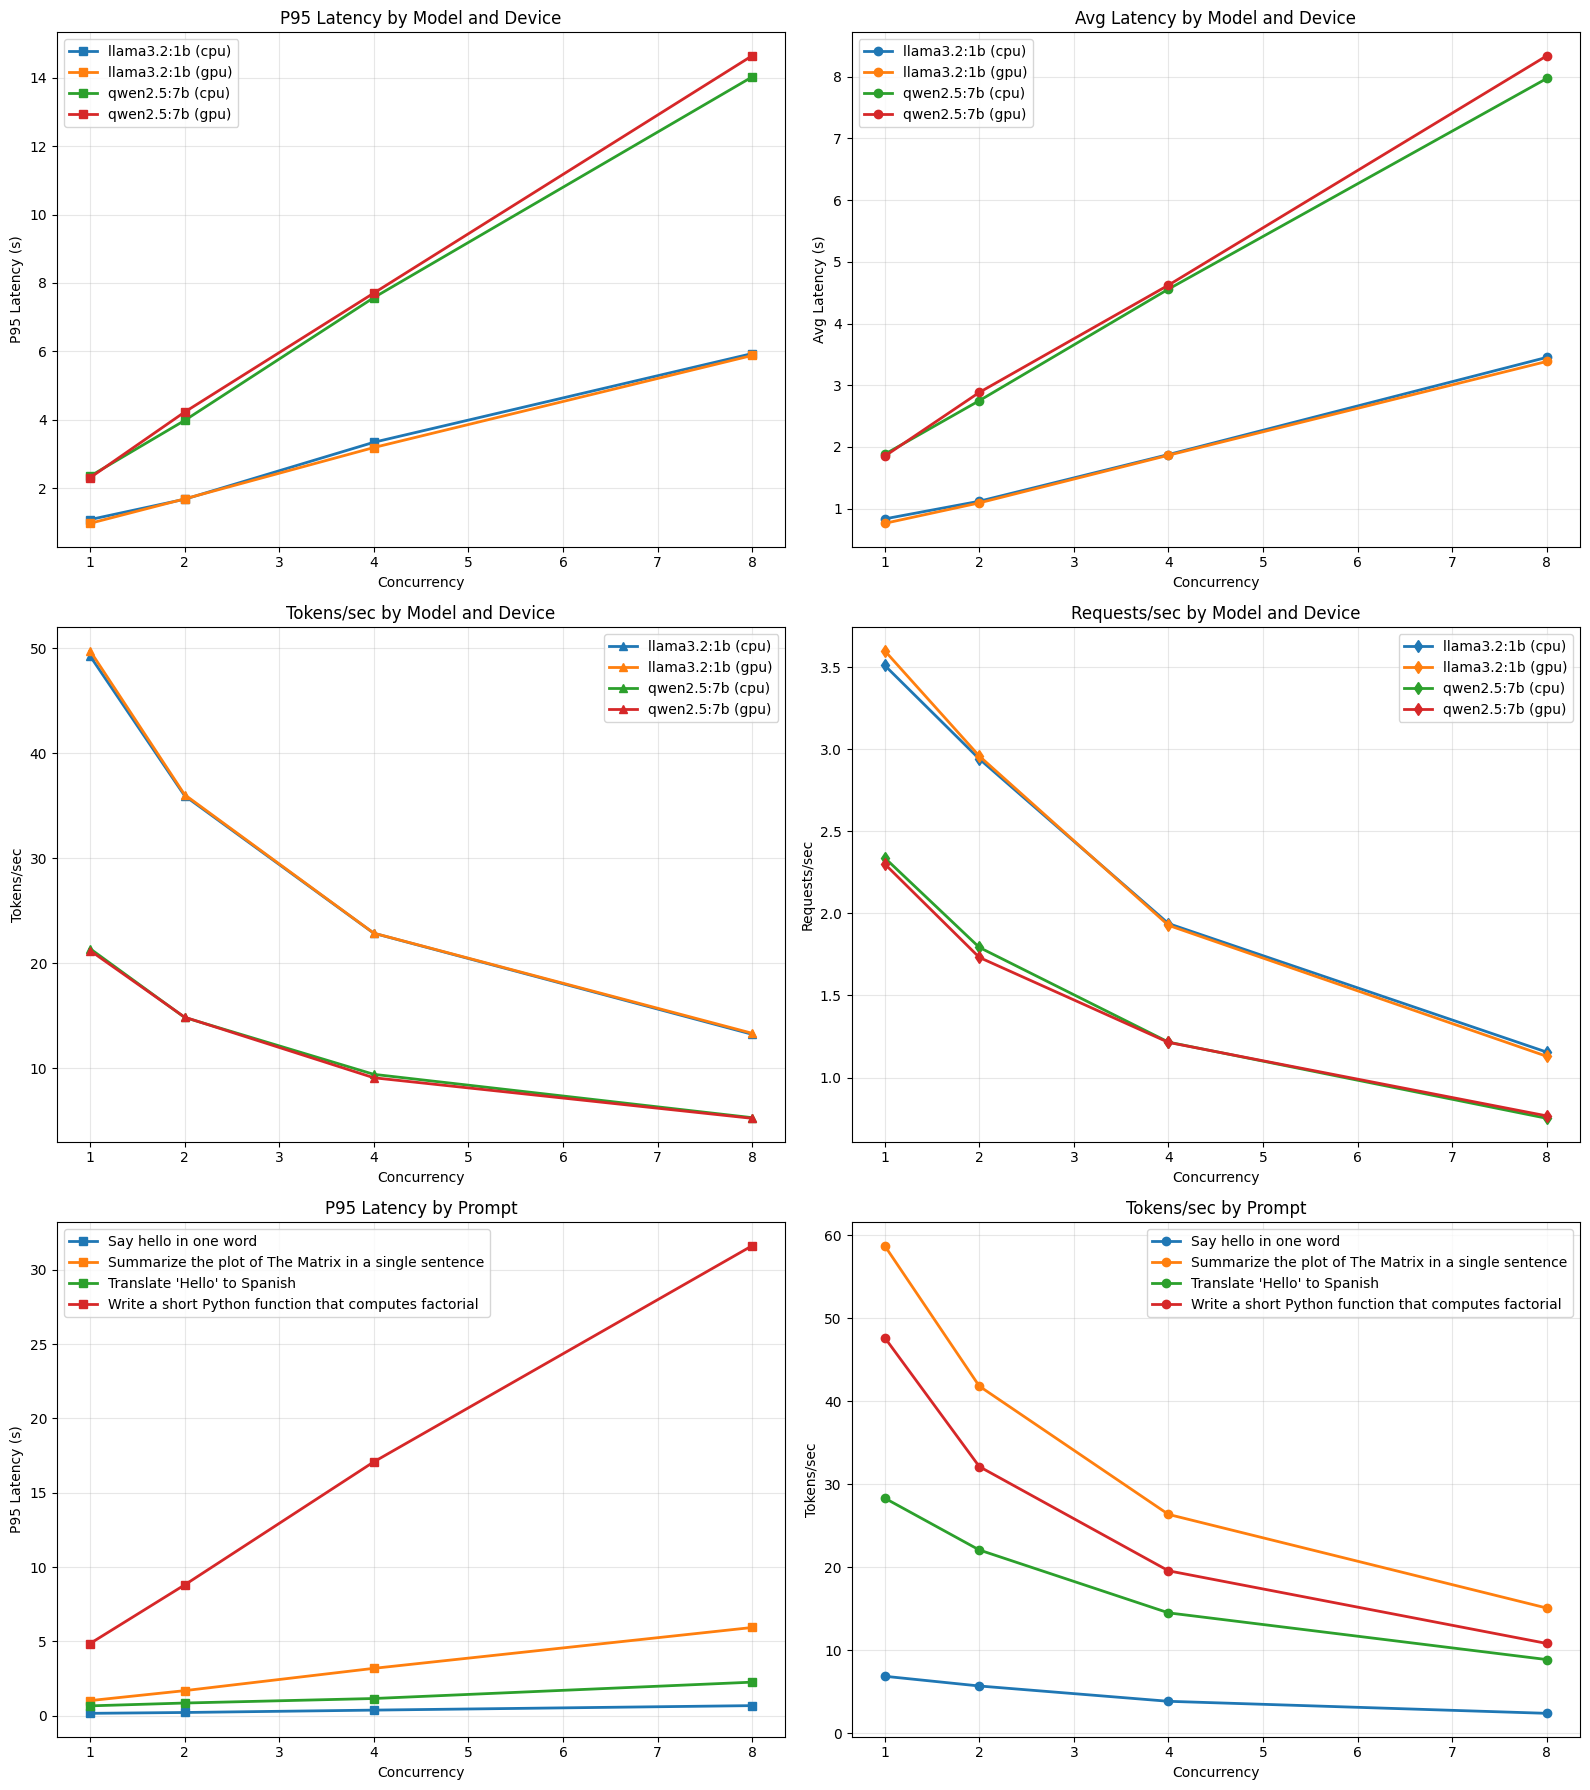

In [27]:
def style_axes(ax):
    ax.grid(True, alpha=0.3)
    ax.legend()

model_device_df = df.groupby(['model', 'device', 'concurrency'], as_index=False).agg({
    'p95_latency': 'mean',
    'avg_latency': 'mean',
    'tokens_per_sec': 'mean',
    'requests_per_sec': 'mean',
}).reset_index(drop=True)

prompt_df = df.groupby(['prompt', 'concurrency'], as_index=False).agg({
    'p95_latency': 'mean',
    'tokens_per_sec': 'mean',
}).reset_index(drop=True)

fig, axes = plt.subplots(3, 2, figsize=(16, 18))

for (model, device), group in model_device_df.groupby(['model', 'device']):
    group = group.sort_values('concurrency')
    label = f'{model} ({device})'
    axes[0, 0].plot(group['concurrency'], group['p95_latency'], marker='s', label=label, linewidth=2)
    axes[0, 1].plot(group['concurrency'], group['avg_latency'], marker='o', label=label, linewidth=2)
    axes[1, 0].plot(group['concurrency'], group['tokens_per_sec'], marker='^', label=label, linewidth=2)
    axes[1, 1].plot(group['concurrency'], group['requests_per_sec'], marker='d', label=label, linewidth=2)

axes[0, 0].set_title('P95 Latency by Model and Device')
axes[0, 0].set_xlabel('Concurrency')
axes[0, 0].set_ylabel('P95 Latency (s)')
style_axes(axes[0, 0])

axes[0, 1].set_title('Avg Latency by Model and Device')
axes[0, 1].set_xlabel('Concurrency')
axes[0, 1].set_ylabel('Avg Latency (s)')
style_axes(axes[0, 1])

axes[1, 0].set_title('Tokens/sec by Model and Device')
axes[1, 0].set_xlabel('Concurrency')
axes[1, 0].set_ylabel('Tokens/sec')
style_axes(axes[1, 0])

axes[1, 1].set_title('Requests/sec by Model and Device')
axes[1, 1].set_xlabel('Concurrency')
axes[1, 1].set_ylabel('Requests/sec')
style_axes(axes[1, 1])

for prompt, group in prompt_df.groupby('prompt'):
    group = group.sort_values('concurrency')
    axes[2, 0].plot(group['concurrency'], group['p95_latency'], marker='s', label=prompt, linewidth=2)
axes[2, 0].set_title('P95 Latency by Prompt')
axes[2, 0].set_xlabel('Concurrency')
axes[2, 0].set_ylabel('P95 Latency (s)')
style_axes(axes[2, 0])

for prompt, group in prompt_df.groupby('prompt'):
    group = group.sort_values('concurrency')
    axes[2, 1].plot(group['concurrency'], group['tokens_per_sec'], marker='o', label=prompt, linewidth=2)
axes[2, 1].set_title('Tokens/sec by Prompt')
axes[2, 1].set_xlabel('Concurrency')
axes[2, 1].set_ylabel('Tokens/sec')
style_axes(axes[2, 1])

plt.tight_layout()
plt.show()


In [28]:
overall = df.groupby(['model_size', 'device']).agg({'avg_latency':'mean', 'p95_latency':'mean', 'tokens_per_sec':'mean'}).reset_index()
best_latency = overall.loc[overall['avg_latency'].idxmin()]
best_throughput = overall.loc[overall['tokens_per_sec'].idxmax()]
worst_prompt = df.groupby('prompt')['p95_latency'].mean().idxmax()
highest_p95 = df.groupby('prompt')['p95_latency'].mean().max()
cpu_avg = overall.loc[overall['device'] == 'cpu', 'avg_latency'].mean()
gpu_avg = overall.loc[overall['device'] == 'gpu', 'avg_latency'].mean()
summary_text = f'''# Summary

- Best average latency: {best_latency['avg_latency']:.3f}s for {best_latency['model_size']} models on {best_latency['device']}.
- Best token throughput: {best_throughput['tokens_per_sec']:.2f} tokens/sec for {best_throughput['model_size']} models on {best_throughput['device']}.
- Highest mean p95 latency: "{worst_prompt}" at {highest_p95:.3f}s.
- GPU inference generally {'appears to' if gpu_avg < cpu_avg else 'does not appear to'} improve average latency across models (cpu={cpu_avg:.3f}, gpu={gpu_avg:.3f}).
'''
display(Markdown(summary_text))


# Summary

- Best average latency: 1.777s for small models on gpu.
- Best token throughput: 30.50 tokens/sec for small models on gpu.
- Highest mean p95 latency: "Write a short Python function that computes factorial" at 15.586s.
- GPU inference generally does not appear to improve average latency across models (cpu=3.056, gpu=3.100).


# additional findings on mlx results

MLX Limitation: MLX's generate() does not support batch inference. Attempting to pass multiple prompts fails with "Invalid type str received in array initialization." This means request-level batching provides no throughput benefit without manual tensor manipulation.